# Boundary Conditions for Isafjardardjup (210x296 Grid)

This notebook creates boundary condition files for the Isafjardardju fjord simulation.

## Grid Configuration
- Bathymetry: `Isafjardardjup_bathymetry210x296.nc`
- Grid dimensions: 210 x 296 (downsampled by factor of 2)
- Vertical levels: 29 layers with **negative** z-coordinates (Oceananigans convention)

## Boundary Data Sources
1. **Ocean boundaries**: CMEMS reanalysis data
2. **River inputs**: Rescaled from Þverá

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.ndimage import gaussian_filter, label
from scipy.spatial import cKDTree
from scipy.interpolate import interp1d

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load Bathymetry Grid

Load the new bathymetry file to get grid dimensions and coordinates.

In [2]:
# Load bathymetry file
bathy_path = r"C:/Users/fisa/Documents/Isafjord/input/Isafjord_bathymetry_210x256.nc"
bathy = xr.open_dataset(bathy_path)
print("=== Bathymetry File ===")
print(f"\nGrid dimensions: {bathy.dims}")

=== Bathymetry File ===

Grid dimensions: FrozenMappingWarningOnValuesAccess({'y': 210, 'x': 256, 'z': 29})


In [3]:
# Extract grid parameters
# Note: h is stored as negative values (depth below surface)
# We negate it to get positive depth for visualization
grid_depth = -bathy['h'].values  # Make positive for visualization
lat_centers = bathy['lat'].values
lon_centers = bathy['lon'].values
z_faces = bathy['z_faces'].values  # Already negative, ordered from deepest to surface

# Grid dimensions
nx = len(lon_centers)
ny = len(lat_centers)
nz = len(z_faces) - 1  # Number of vertical layers

print(f"Grid size: {nx} x {ny} x {nz}")
print(f"Latitude range: {lat_centers.min():.4f}°N to {lat_centers.max():.4f}°N")
print(f"Longitude range: {lon_centers.min():.4f}°E to {lon_centers.max():.4f}°E")
print(f"Depth range: {grid_depth[grid_depth > 0].min():.1f}m to {grid_depth.max():.1f}m")
print(f"Vertical levels: {nz} layers (z_faces: {z_faces[0]:.0f}m to {z_faces[-1]:.0f}m)")
print(f"Wet cells: {np.sum(grid_depth > 0)} ({100*np.sum(grid_depth > 0)/(nx*ny):.1f}%)")

Grid size: 256 x 210 x 28
Latitude range: 65.7600°N to 66.1780°N
Longitude range: -23.3200°E to -22.3000°E
Depth range: 10.0m to 162.4m
Vertical levels: 28 layers (z_faces: -160m to -0m)
Wet cells: 13124 (24.4%)


In [4]:
# Calculate z_centers from z_faces
# z_faces are ordered from deepest (most negative) to surface (0)
z_centers = [(z_faces[i] + z_faces[i+1]) / 2 for i in range(len(z_faces) - 1)]
print(f"z_centers ({len(z_centers)} levels):")
print(f"  Deepest: {[f'{z:.1f}' for z in z_centers[:5]]}")
print(f"  Surface: {[f'{z:.1f}' for z in z_centers[-5:]]}")

z_centers (28 levels):
  Deepest: ['-155.0', '-145.0', '-135.0', '-125.0', '-115.0']
  Surface: ['-4.5', '-3.5', '-2.5', '-1.5', '-0.8']


## 2. Visualize Bathymetry

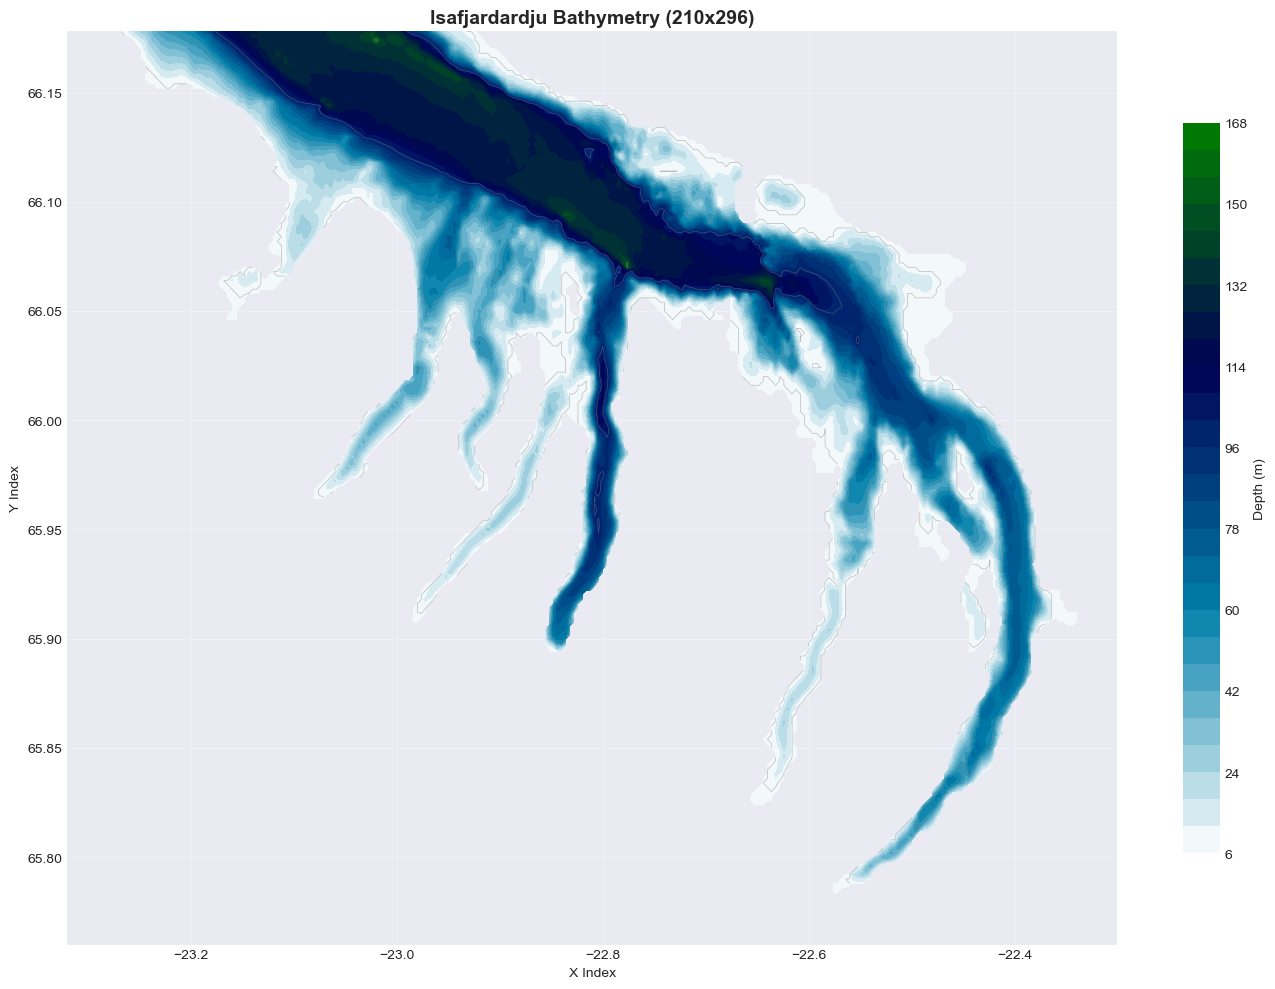

In [5]:
# Plot bathymetry
fig, ax = plt.subplots(figsize=(14, 10))
depth_plot = np.where(grid_depth == 0, np.nan, grid_depth)
cf = ax.contourf(lon_centers, lat_centers, depth_plot, levels=25, cmap='ocean_r')
ax.contour(lon_centers, lat_centers, depth_plot, levels=[10, 50, 100, 150], colors='gray', alpha=0.5, linewidths=0.5)
plt.colorbar(cf, ax=ax, label='Depth (m)', shrink=0.8)
ax.set_title('Isafjardardju Bathymetry (210x296)', fontsize=14, fontweight='bold')
ax.set_xlabel('X Index')
ax.set_ylabel('Y Index')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Load CMEMS Ocean Data

Load CMEMS reanalysis data for ocean boundary conditions.

In [6]:
# Load CMEMS data (adjust filename as needed)
cmems_file = "nesting/cmems/P1D-m_1745438014042.nc"
cmems = xr.open_dataset(cmems_file).isel(depth=slice(0, 21))
print("=== CMEMS Data ===")
print(f"\nTime range: {cmems.time.values[0]} to {cmems.time.values[-1]}")
print(f"Vertical levels: {len(cmems.depth)} ({cmems.depth.min().values:.1f}m to {cmems.depth.max().values:.1f}m)")

=== CMEMS Data ===

Time range: 1991-01-01T00:00:00.000000000 to 1992-01-01T00:00:00.000000000
Vertical levels: 21 (-0.0m to 250.0m)


## 4. Extract Boundary Conditions from CMEMS

Extract ocean boundary conditions at the western edge (open ocean) of the domain.

In [7]:
# Define boundary location (westernmost longitude for open ocean)
lon_boundary = -25.0  # Adjust based on CMEMS coverage

# Subset CMEMS data for boundary
cmems_boundary = cmems.sel(longitude=lon_boundary, latitude=lat_centers, method='nearest')

print(f"Boundary location: {lon_boundary}°E")
print(f"Extracted data shape: time={len(cmems_boundary.time)}, depth={len(cmems_boundary.depth)}, lat={len(cmems_boundary.latitude)}")

Boundary location: -25.0°E
Extracted data shape: time=366, depth=21, lat=210


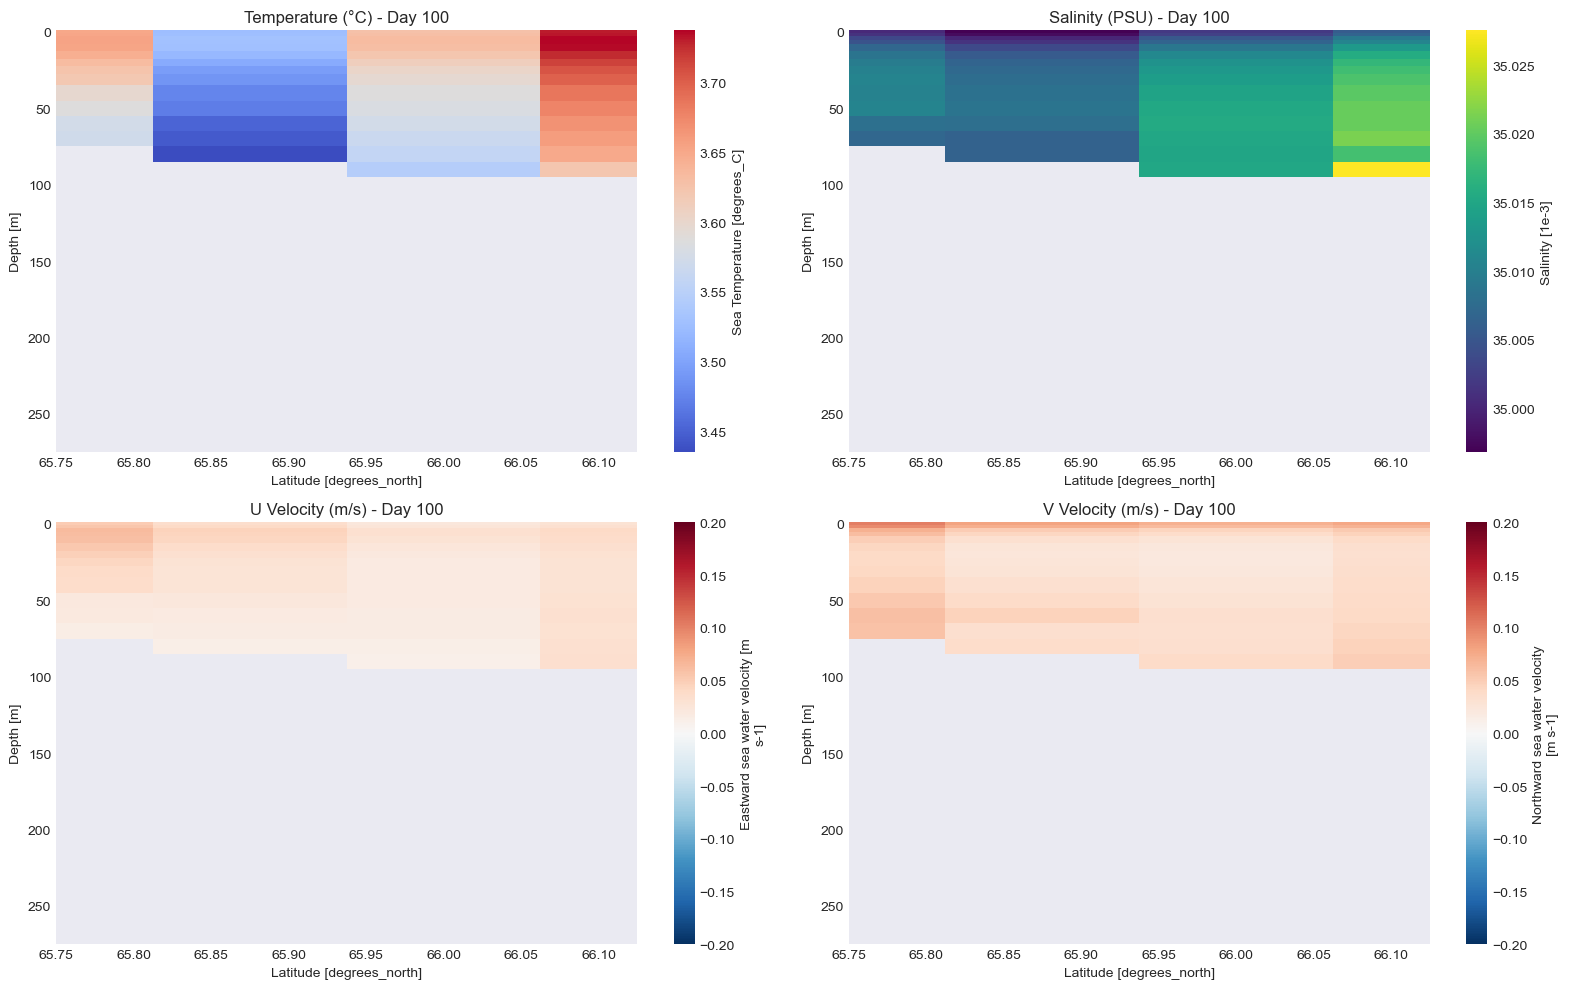

In [8]:
# Visualize boundary conditions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Temperature
cmems_boundary.thetao.isel(time=100).plot(ax=axes[0, 0], cmap='coolwarm')
axes[0, 0].set_title('Temperature (°C) - Day 100')
axes[0, 0].invert_yaxis()

# Salinity
cmems_boundary.so.isel(time=100).plot(ax=axes[0, 1], cmap='viridis')
axes[0, 1].set_title('Salinity (PSU) - Day 100')
axes[0, 1].invert_yaxis()

# U velocity
cmems_boundary.vxo.isel(time=100).plot(ax=axes[1, 0], cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1, 0].set_title('U Velocity (m/s) - Day 100')
axes[1, 0].invert_yaxis()

# V velocity
cmems_boundary.vyo.isel(time=100).plot(ax=axes[1, 1], cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1, 1].set_title('V Velocity (m/s) - Day 100')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Interpolate to Model Grid

Interpolate CMEMS data to the model's vertical grid (z_centers).

In [9]:
cmems_boundary

<xarray.Dataset> Size: 26MB
Dimensions:      (time: 366, depth: 21, latitude: 210)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1992-01-01
  * depth        (depth) float32 84B -0.0 2.0 4.0 6.0 ... 175.0 200.0 250.0
  * latitude     (latitude) float32 840B 65.75 65.75 65.75 ... 66.12 66.12 66.12
    longitude    float32 4B -25.0
Data variables:
    so           (time, depth, latitude) float32 6MB ...
    thetao       (time, depth, latitude) float32 6MB ...
    vxo          (time, depth, latitude) float32 6MB ...
    model_depth  (latitude) float32 840B ...
    vyo          (time, depth, latitude) float32 6MB ...
    zos          (time, latitude) float32 307kB ...
    sithick      (time, latitude) float32 307kB ...
Attributes:
    Conventions:       CF-1.11
    title:             Arctic Ocean Physics Reanalysis
    institution:       NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:            NERSC-HYCOM model fields
    history:           20220829:Created by program hyc2proj, version V0.3
    references:        http://topaz.nersc.no
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  ARCTIC_MULTIYEAR_PHY_002_003
    subset:datasetId:  cmems_mod_arc_phy_my_topaz4_P1D-m_202211
    subset:date:       2025-04-23T19:53:34.043Z

In [10]:
# Prepare CMEMS data for interpolation
if cmems_boundary.depth.values[1] > 0:
    cmems_boundary['depth'] = -cmems_boundary.depth

# Rename variables
ds_interp = cmems_boundary.rename({
    'longitude': 'Nx',
    'latitude': 'Ny', 
    'depth': 'Nz',
    'thetao': 'T',
    'so': 'S',
    'vxo': 'u',
    'vyo': 'v'
})

print("Interpolating to model vertical grid...")
print(f"Original depth levels: {len(ds_interp.Nz)}")
print(f"Target depth levels (z_centers): {len(z_centers)}")
print(f"z_centers range: {z_centers[0]:.1f}m to {z_centers[-1]:.1f}m")

Interpolating to model vertical grid...
Original depth levels: 21
Target depth levels (z_centers): 28
z_centers range: -155.0m to -0.8m


In [11]:
# Interpolate to z_centers
# Note: This may take a minute
ds_interp = ds_interp.interp(Nz=z_centers, method='linear')

# Forward fill NaN values at depth (below CMEMS coverage)
ds_interp = ds_interp.bfill(dim='Nz')

print("✓ Interpolation complete")
print(f"Interpolated shape: {ds_interp.dims}")

✓ Interpolation complete
Interpolated shape: FrozenMappingWarningOnValuesAccess({'time': 366, 'Ny': 210, 'Nz': 28})


In [12]:
ds_interp

<xarray.Dataset> Size: 69MB
Dimensions:      (time: 366, Ny: 210, Nz: 28)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1992-01-01
  * Ny           (Ny) float32 840B 65.75 65.75 65.75 65.75 ... 66.12 66.12 66.12
  * Nz           (Nz) float64 224B -155.0 -145.0 -135.0 ... -2.5 -1.5 -0.75
    Nx           float32 4B -25.0
Data variables:
    S            (time, Nz, Ny) float64 17MB 35.03 35.03 35.03 ... 35.05 35.05
    T            (time, Nz, Ny) float64 17MB 4.7 4.7 4.7 4.7 ... 4.51 4.51 4.51
    u            (time, Nz, Ny) float64 17MB 0.02076 0.02076 ... 0.03666 0.03666
    model_depth  (Ny) float32 840B ...
    v            (time, Nz, Ny) float64 17MB 0.03575 0.03575 ... -0.01018
    zos          (time, Ny) float32 307kB ...
    sithick      (time, Ny) float32 307kB ...
Attributes:
    Conventions:       CF-1.11
    title:             Arctic Ocean Physics Reanalysis
    institution:       NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:            NERSC-HYCOM model fields
    history:           20220829:Created by program hyc2proj, version V0.3
    references:        http://topaz.nersc.no
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  ARCTIC_MULTIYEAR_PHY_002_003
    subset:datasetId:  cmems_mod_arc_phy_my_topaz4_P1D-m_202211
    subset:date:       2025-04-23T19:53:34.043Z

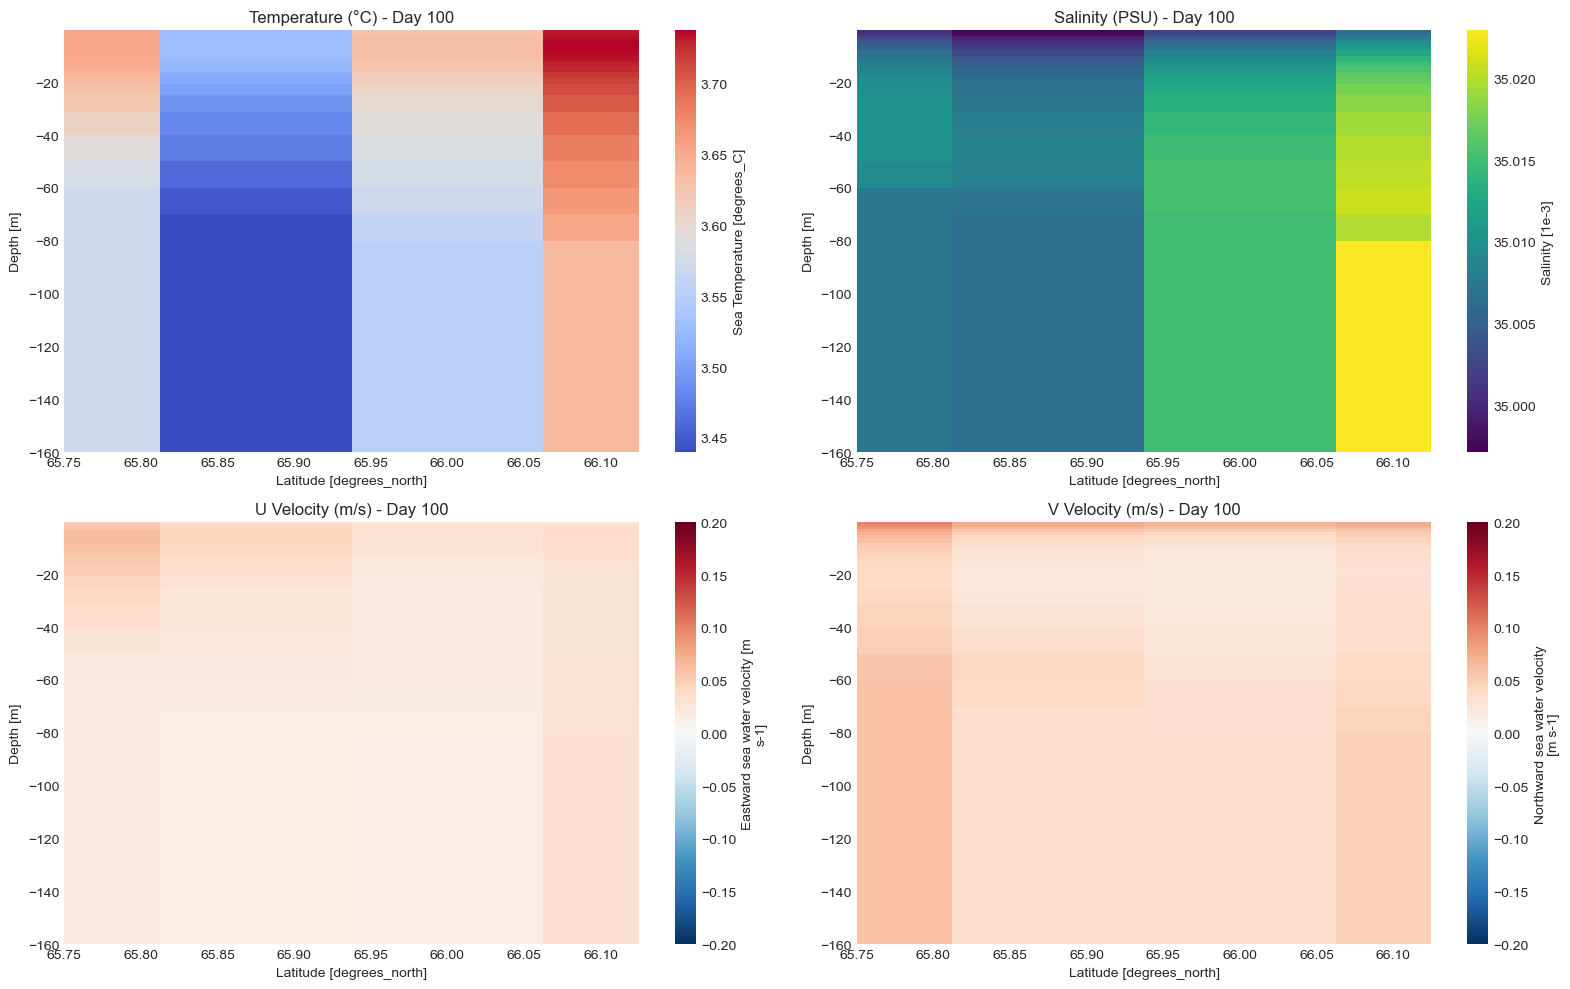

In [13]:
# Visualize boundary conditions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Temperature
ds_interp.T.isel(time=100).plot(ax=axes[0, 0], cmap='coolwarm')
axes[0, 0].set_title('Temperature (°C) - Day 100')

# Salinity
ds_interp.S.isel(time=100).plot(ax=axes[0, 1], cmap='viridis')
axes[0, 1].set_title('Salinity (PSU) - Day 100')

# U velocity
ds_interp.u.isel(time=100).plot(ax=axes[1, 0], cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1, 0].set_title('U Velocity (m/s) - Day 100')

# V velocity
ds_interp.v.isel(time=100).plot(ax=axes[1, 1], cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1, 1].set_title('V Velocity (m/s) - Day 100')

plt.tight_layout()
plt.show()

## 6. Prepare Boundary Arrays

Create arrays for boundary conditions on the model grid.

In [14]:
# Number of time steps (use subset for testing)
nt = len(ds_interp.time)
print(f"Time steps: {nt}")

# Initialize arrays
print(f"\nInitializing arrays with shape:")
print(f"  T, S: (nt={nt}, nz={nz}, ny={ny}, nx={nx})")
print(f"  u: (nt={nt}, nz={nz}, ny={ny}, nx+1={nx+1})")
print(f"  v: (nt={nt}, nz={nz}, ny+1={ny+1}, nx={nx})")

np_temp = np.full((nt, nz, ny, nx), -999, dtype=np.float32)
np_salt = np.full((nt, nz, ny, nx), -999, dtype=np.float32)
#np_u = np.full((nt, nz, ny, nx+1), -999, dtype=np.float32)
np_v = np.full((nt, nz, ny+1, nx), -999, dtype=np.float32)

print("✓ Arrays initialized")

Time steps: 366

Initializing arrays with shape:
  T, S: (nt=366, nz=28, ny=210, nx=256)
  u: (nt=366, nz=28, ny=210, nx+1=257)
  v: (nt=366, nz=28, ny+1=211, nx=256)
✓ Arrays initialized


In [15]:
# Extract and smooth boundary data
print("Applying Gaussian smoothing...")
tcmems = gaussian_filter(ds_interp['T'].values, sigma=(0.2, 0.1, 3))
scmems = gaussian_filter(ds_interp['S'].values, sigma=(0.2, 0.1, 3))
ucmems = gaussian_filter(ds_interp['u'].values, sigma=(0.2, 0.1, 3))
vcmems = gaussian_filter(ds_interp['v'].values, sigma=(0.2, 0.1, 3))

print(f"✓ Smoothing complete")
print(f"  T range: {tcmems.min():.2f} to {tcmems.max():.2f} °C")
print(f"  S range: {scmems.min():.2f} to {scmems.max():.2f} PSU")
print(f"  u range: {ucmems.min():.3f} to {ucmems.max():.3f} m/s")
print(f"  v range: {vcmems.min():.3f} to {vcmems.max():.3f} m/s")

Applying Gaussian smoothing...
✓ Smoothing complete
  T range: 3.29 to 12.30 °C
  S range: 34.26 to 35.09 PSU
  u range: -0.506 to 0.271 m/s
  v range: -0.336 to 0.406 m/s


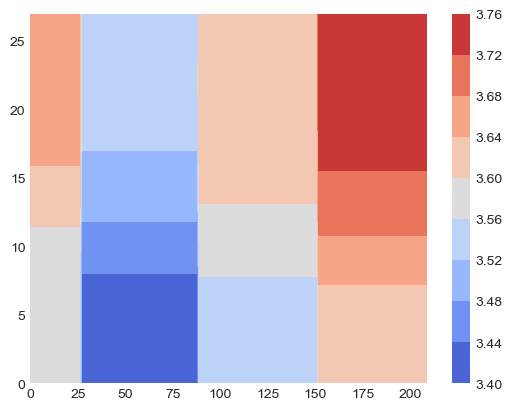

In [16]:
plt.contourf(ds_interp['T'].isel(time=100), cmap='coolwarm')
plt.colorbar()

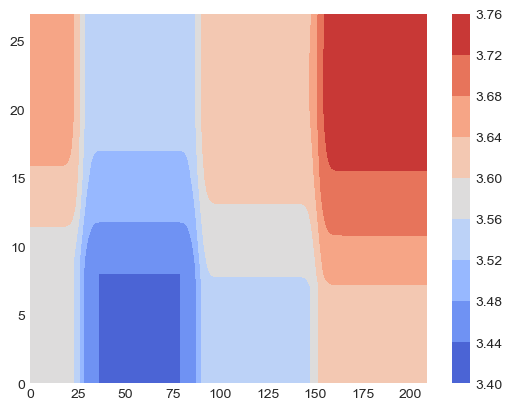

In [17]:
plt.contourf(tcmems[100, :,:], cmap='coolwarm')
plt.colorbar()

In [18]:
tcmems.shape

(366, 28, 210)

In [19]:
vcmems.shape

(366, 28, 210)

In [20]:
np_temp.shape

(366, 28, 210, 256)

In [21]:
# Apply boundary conditions

# Extend v to include boundary face
vcmems_extended = np.concatenate((vcmems, vcmems[:, :, -1:]), axis=2)
#np_v[:, :, :, 0] = vcmems_extended

# Northern boundary (y=-1, northern edge)
# Repeat last latitude value across all longitudes
np_temp[:, :, -1, :] = np.repeat(tcmems[:, :, -1:], nx, axis=2)
np_salt[:, :, -1, :] = np.repeat(scmems[:, :, -1:], nx, axis=2)
#np_u[:, :, -1, :] = np.repeat(ucmems[:, :, -1:], nx+1, axis=2)
np_v[:, :, -1, :] = np.repeat(vcmems[:, :, -1:], nx, axis=2)

print("✓ Boundary conditions applied")

✓ Boundary conditions applied


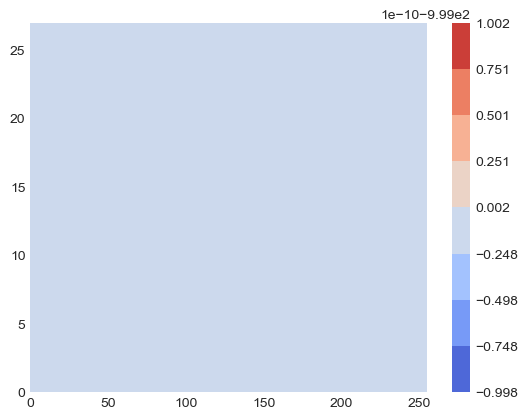

In [22]:
plt.contourf(np_v[100,:, -2, :], cmap='coolwarm')
plt.colorbar()

In [23]:
depth_plot.shape

(210, 256)

In [24]:
np_v[100,:, -3, :].max()

np.float32(-999.0)

In [25]:
np_temp.shape

(366, 28, 210, 256)

## 7. Load River Data

Load river information from NetCDF file containing discharge data and locations.

In [26]:
# Load river data from NetCDF file
river_file = r"C:\Users\fisa\Documents\fjordssim-notebooks\Isafjord\input\bry\rivers\isafjord_rivers_1991.nc"
rivers_ds = xr.open_dataset(river_file)

print("=== River Dataset ===")
print(rivers_ds)
print(f"\nNumber of rivers: {len(rivers_ds.river)}")
print(f"Time range: {len(rivers_ds.time)} days")

# Extract river information
river_names = [name.strip() if isinstance(name, str) else str(name).strip() for name in rivers_ds.river_name.values]
river_lats = rivers_ds.river_lat.values
river_lons = rivers_ds.river_lon.values

# Filter out rivers with missing location data
valid_rivers = (
    ~np.isnan(river_lats)
    & ~np.isnan(river_lons)
)
river_names = [name for i, name in enumerate(river_names) if valid_rivers[i]]
river_lats = river_lats[valid_rivers]
river_lons = river_lons[valid_rivers]
river_indices = np.where(valid_rivers)[0]

print(f"\nRivers with valid locations: {len(river_names)}")
print("\n=== River Locations (first 10) ===")
for i, (name, lat, lon) in enumerate(zip(river_names[:10], river_lats[:10], river_lons[:10])):
    print(f"{name:30s}: {lat:7.4f}°N, {lon:8.4f}°E")

=== River Dataset ===
<xarray.Dataset> Size: 383kB
Dimensions:          (river: 64, time: 365)
Coordinates:
  * river            (river) int64 512B 0 1 2 3 4 5 6 7 ... 57 58 59 60 61 62 63
  * time             (time) datetime64[ns] 3kB 1991-01-01 ... 1991-12-31
    river_lon        (river) float64 512B ...
    river_lat        (river) float64 512B ...
Data variables:
    river_name       (river) <U17 4kB ...
    river_scale      (river) float64 512B ...
    river_discharge  (time, river) float64 187kB ...
    river_transport  (time, river) float64 187kB ...
Attributes:
    title:            River forcing for Isafjord, Iceland - Year 1991
    description:      Daily river discharge data for 1991. Discharge scaled f...
    institution:      Iceland Ocean Model
    source:           Þverá observations from tvera_discharge.csv; Scaling fa...
    history:          Created 2025-12-01 11:11:01
    references:       Daily discharge interpolated from seasonal observations
    Conventions:      

## Filter Rivers by Domain and Distance

Filter out rivers that are:
1. Outside the model domain boundaries
2. More than 2 km from the nearest wet grid cell

In [27]:
# First filter: Remove rivers outside domain boundaries
lat_min, lat_max = lat_centers.min(), lat_centers.max()
lon_min, lon_max = lon_centers.min(), lon_centers.max()

in_domain = (
    (river_lats >= lat_min) & (river_lats <= lat_max) &
    (river_lons >= lon_min) & (river_lons <= lon_max)
)

print(f"Rivers in domain bounds: {in_domain.sum()} / {len(river_names)}")
print(f"Domain: Lat [{lat_min:.4f}, {lat_max:.4f}], Lon [{lon_min:.4f}, {lon_max:.4f}]")

# Apply domain filter
river_names_filtered = [name for i, name in enumerate(river_names) if in_domain[i]]
river_lats_filtered = river_lats[in_domain]
river_lons_filtered = river_lons[in_domain]
river_indices_filtered = river_indices[in_domain]

print(f"\nRivers removed (outside domain): {len(river_names) - len(river_names_filtered)}")

Rivers in domain bounds: 26 / 62
Domain: Lat [65.7600, 66.1780], Lon [-23.3200, -22.3000]

Rivers removed (outside domain): 36


In [28]:
grid_depth.shape

(210, 256)

In [29]:
# Find nearest grid cells for rivers
valid_mask = grid_depth > 0
valid_indices = np.argwhere(valid_mask)

# Create 2D lon/lat grids
lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
valid_lons = lon_grid_2d[valid_mask]
valid_lats = lat_grid_2d[valid_mask]

# Build KD-tree
tree = cKDTree(np.column_stack([valid_lats, valid_lons]))

# Calculate distances and filter by 1 km threshold
# Convert 1 km to approximate degrees (at ~66°N latitude)
R_earth = 6371e3  # Earth radius in meters
avg_lat = np.mean(river_lats_filtered)
km_to_deg_lat = 2000 / (R_earth * np.radians(1))
km_to_deg_lon = 2000 / (R_earth * np.radians(1) * np.cos(np.radians(avg_lat)))
distance_threshold = np.sqrt(km_to_deg_lat**2 + km_to_deg_lon**2)  # Conservative estimate

print(f"\nDistance threshold: ~{distance_threshold:.4f}° (~2 km)")

# Find nearest grid points and filter by distance
xrivers = []
yrivers = []
river_grid_indices = []
river_names_final = []
river_distances = []

print("\n=== River Grid Mapping (within 1 km) ===")
rivers_rejected = 0
for i, (name, rlat, rlon, ridx) in enumerate(zip(river_names_filtered, river_lats_filtered, river_lons_filtered, river_indices_filtered)):
    dist, idx = tree.query([rlat, rlon])
    
    if dist <= distance_threshold:
        y_idx, x_idx = valid_indices[idx]
        xrivers.append(x_idx)
        yrivers.append(y_idx)
        river_grid_indices.append(ridx)
        river_names_final.append(name)
        river_distances.append(dist)
        
        # Convert distance to km
        dist_km = dist * R_earth * np.radians(1) / 1000
        print(f"{name:30s}: Grid ({x_idx:3d}, {y_idx:3d}), Distance: {dist_km:.2f} km, Depth: {grid_depth[y_idx, x_idx]:6.1f}m")
    else:
        rivers_rejected += 1

print(f"\nRivers removed (>2 km from grid): {rivers_rejected}")
print(f"✓ Final river count: {len(xrivers)} rivers mapped to grid")


Distance threshold: ~0.0478° (~2 km)

=== River Grid Mapping (within 1 km) ===
Arnardalsá                    : Grid ( 67, 169), Distance: 0.26 km, Depth:   10.0m
Blævardalsá                   : Grid (232, 107), Distance: 0.20 km, Depth:   10.3m
Dalsá                         : Grid (183, 172), Distance: 0.21 km, Depth:   10.0m
Eyrardalsá                    : Grid ( 84, 135), Distance: 0.51 km, Depth:   16.6m
Gljúfurá                      : Grid (182,  72), Distance: 0.22 km, Depth:   10.0m
Hafnardalsá                   : Grid (235,  88), Distance: 0.19 km, Depth:   10.0m
Hattardalsá                   : Grid ( 68, 106), Distance: 0.68 km, Depth:   10.0m
Hestfjarðará                  : Grid ( 84,  74), Distance: 0.28 km, Depth:   10.0m
Hnífsdalsá                    : Grid ( 50, 177), Distance: 0.32 km, Depth:   10.0m
Hólsá                         : Grid ( 19, 198), Distance: 0.49 km, Depth:   10.0m
Innri-Skarðsá                 : Grid (154, 183), Distance: 0.25 km, Depth:   10.0m
Langada

✓ Plotted 26 river locations


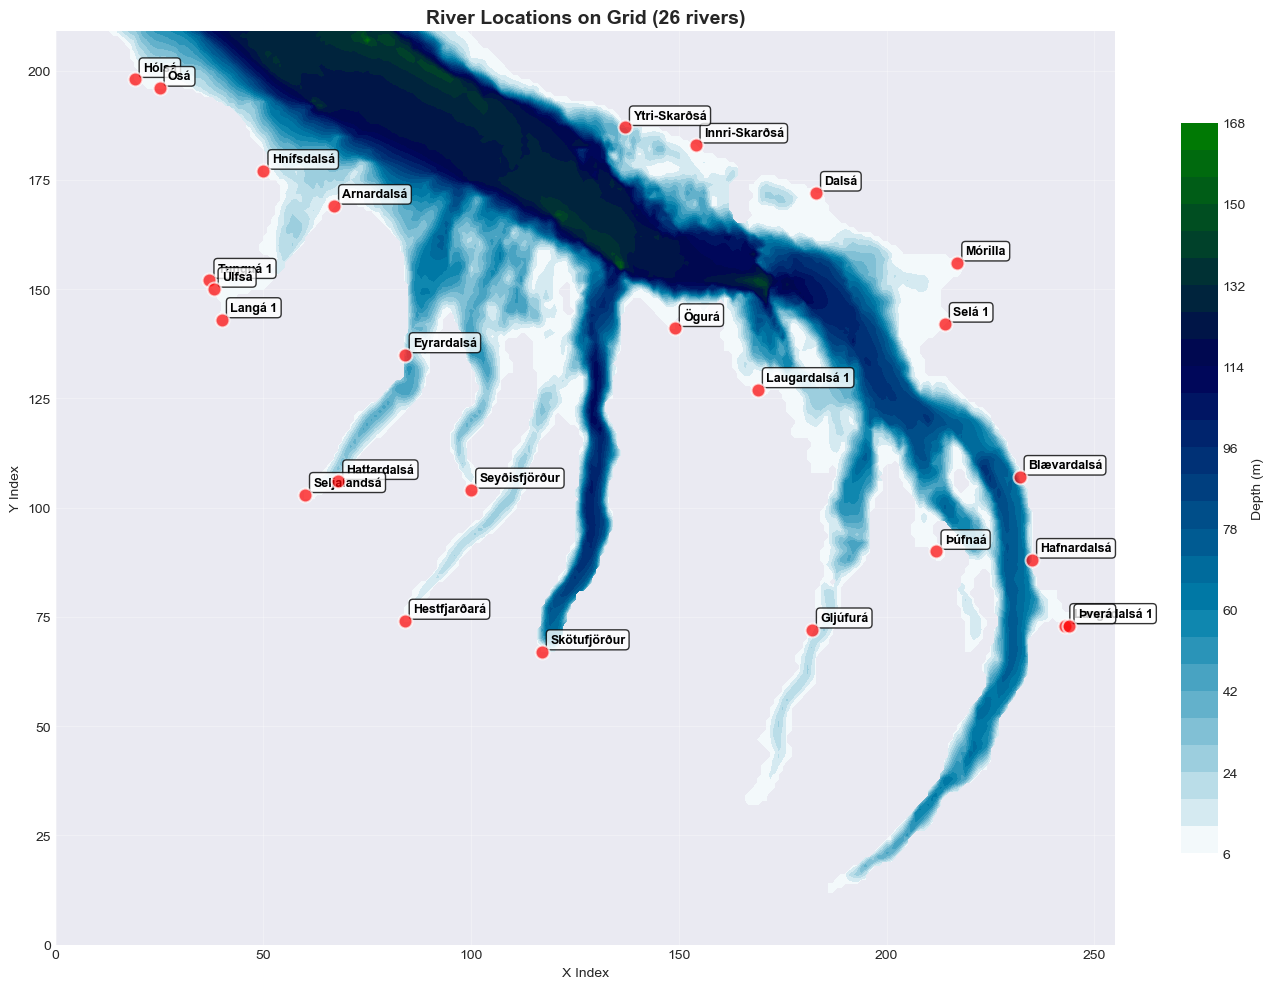

In [30]:
# Visualize river locations
fig, ax = plt.subplots(figsize=(14, 10))
cf = ax.contourf(depth_plot, levels=25, cmap='ocean_r')

# Plot all rivers (use filtered river_names_final)
for i, (x, y, name) in enumerate(zip(xrivers, yrivers, river_names_final)):
    ax.scatter(x, y, c='red', s=100, edgecolors='white', linewidths=1.5, zorder=10, alpha=0.7)

    ax.text(x+2, y+2, name, fontsize=9, fontweight='bold', color='k',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.colorbar(cf, ax=ax, label='Depth (m)', shrink=0.8)
ax.set_title(f'River Locations on Grid ({len(xrivers)} rivers)', fontsize=14, fontweight='bold')
ax.set_xlabel('X Index')
ax.set_ylabel('Y Index')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('river_locations_model.png', bbox_inches='tight', dpi=300)
print(f"✓ Plotted {len(xrivers)} river locations")

## 8. Prepare Time-Varying River Discharge

Extract daily discharge data for filtered rivers. This will be used to create time-varying relaxation coefficients.

In [31]:
# Extract discharge data for filtered rivers
# Shape: (time, river)
river_discharge = rivers_ds.river_discharge.values

# Extract discharge for filtered rivers only (shape: time, n_filtered_rivers)
Q_rivers_time365 = river_discharge[:, river_grid_indices]

In [32]:
# add the same values to the end to make 366 days instead of 365
Q_rivers_time = np.append(Q_rivers_time365, [Q_rivers_time365[-1,:]], axis=0)

In [33]:
Q_rivers_time.shape

(366, 26)

In [34]:
# Calculate statistics
mean_Q_rivers = np.mean(Q_rivers_time, axis=0)
max_Q_rivers = np.max(Q_rivers_time, axis=0)
min_Q_rivers = np.min(Q_rivers_time, axis=0)

print("=== River Discharge Statistics (Time-Varying) ===")
print(f"Total rivers: {len(river_names_final)}")
print(f"Time steps: {Q_rivers_time.shape[0]}")
print(f"Rivers with discharge > 0: {np.sum(mean_Q_rivers > 0)}")
print(f"Total mean discharge: {mean_Q_rivers.sum():.2f} m³/s")
print(f"\nTop 10 rivers by mean discharge:")
top_10_idx = np.argsort(mean_Q_rivers)[-10:][::-1]
for idx in top_10_idx:
    if idx < len(river_names_final):
        print(f"  {river_names_final[idx]:30s}: mean={mean_Q_rivers[idx]:6.2f} m³/s, max={max_Q_rivers[idx]:6.2f} m³/s")

=== River Discharge Statistics (Time-Varying) ===
Total rivers: 26
Time steps: 366
Rivers with discharge > 0: 26
Total mean discharge: 150.15 m³/s

Top 10 rivers by mean discharge:
  Mórilla                       : mean= 53.62 m³/s, max=167.56 m³/s
  Selá 1                        : mean= 26.81 m³/s, max= 83.78 m³/s
  Langadalsá 1                  : mean=  8.04 m³/s, max= 25.13 m³/s
  Þúfnaá                        : mean=  2.68 m³/s, max=  8.38 m³/s
  Skötufjörður                  : mean=  2.68 m³/s, max=  8.38 m³/s
  Þverá                         : mean=  2.68 m³/s, max=  8.38 m³/s
  Ögurá                         : mean=  2.68 m³/s, max=  8.38 m³/s
  Ósá                           : mean=  2.68 m³/s, max=  8.38 m³/s
  Úlfsá                         : mean=  2.68 m³/s, max=  8.38 m³/s
  Seyðisfjörður                 : mean=  2.68 m³/s, max=  8.38 m³/s


TOTAL DISCHARGE FROM ALL ASSIGNED RIVERS

=== ANNUAL TOTAL DISCHARGE ===
Number of rivers: 26
Number of days: 366
Mean daily discharge: 150.15 m³/s
Max daily discharge: 469.17 m³/s
Min daily discharge: 2.35 m³/s
Annual total volume: 4.75e+09 m³ (4.7480 km³)

=== MONTHLY TOTAL DISCHARGE ===
Month        Mean (m³/s)     Total (10⁶ m³)     % of Annual 
------------------------------------------------------------
January      60.38           161.73             3.4         
February     47.79           119.74             2.5         
March        24.80           66.42              1.4         
April        90.06           233.45             4.9         
May          266.09          712.70             15.0        
June         428.22          1109.94            23.4        
July         252.64          676.67             14.3        
August       93.35           250.03             5.3         
September    173.16          448.84             9.5         
October      148.43          397.56   

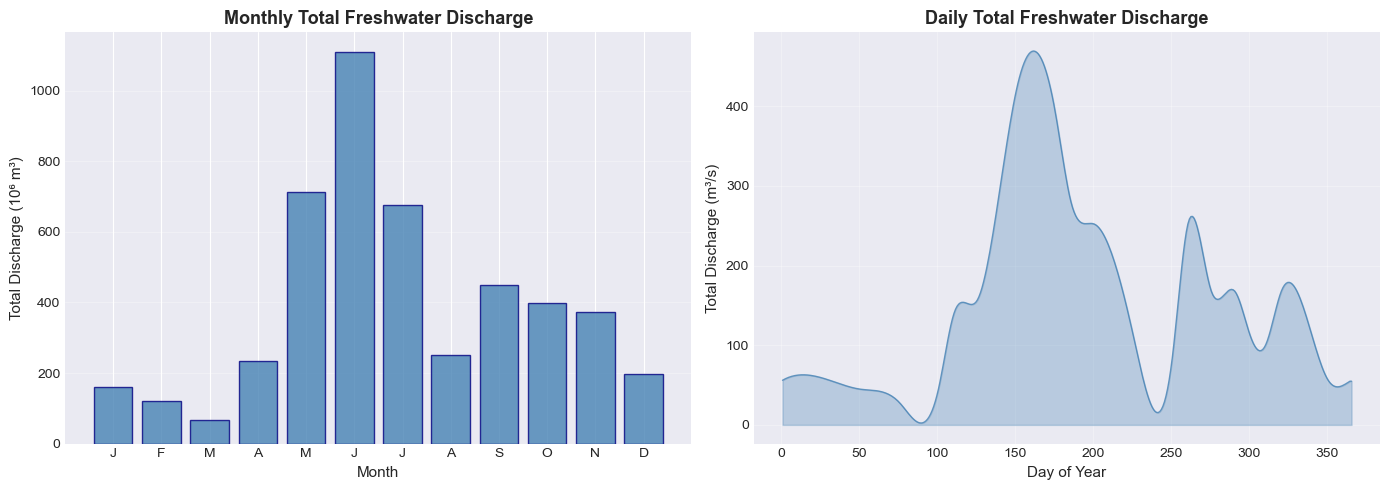


✓ Discharge statistics plot saved: river_discharge_statistics.png


In [35]:
# Calculate annual and monthly total discharge from all rivers assigned to cells
print("=" * 60)
print("TOTAL DISCHARGE FROM ALL ASSIGNED RIVERS")
print("=" * 60)

# Total discharge across all rivers for each time step
total_Q_daily = Q_rivers_time.sum(axis=1)  # Sum across all rivers for each day

# Annual total discharge
# Convert daily m³/s to annual volume: m³/s * seconds/day * days
seconds_per_day = 86400
annual_volume_m3 = total_Q_daily.sum() * seconds_per_day  # Total volume in m³
annual_volume_km3 = annual_volume_m3 / 1e9  # Convert to km³

print(f"\n=== ANNUAL TOTAL DISCHARGE ===")
print(f"Number of rivers: {Q_rivers_time.shape[1]}")
print(f"Number of days: {Q_rivers_time.shape[0]}")
print(f"Mean daily discharge: {total_Q_daily.mean():.2f} m³/s")
print(f"Max daily discharge: {total_Q_daily.max():.2f} m³/s")
print(f"Min daily discharge: {total_Q_daily.min():.2f} m³/s")
print(f"Annual total volume: {annual_volume_m3:.2e} m³ ({annual_volume_km3:.4f} km³)")

# Monthly discharge statistics
print(f"\n=== MONTHLY TOTAL DISCHARGE ===")
print(f"{'Month':<12} {'Mean (m³/s)':<15} {'Total (10⁶ m³)':<18} {'% of Annual':<12}")
print("-" * 60)

# Assume 365 days starting from Jan 1
days_in_month = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
month_names = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Handle leap year (366 days)
if Q_rivers_time.shape[0] == 366:
    days_in_month[1] = 29  # February has 29 days

day_idx = 0
monthly_volumes = []
for month, (name, ndays) in enumerate(zip(month_names, days_in_month)):
    if day_idx + ndays > Q_rivers_time.shape[0]:
        ndays = Q_rivers_time.shape[0] - day_idx
    
    month_Q = total_Q_daily[day_idx:day_idx + ndays]
    mean_Q = month_Q.mean()
    total_volume_m3 = month_Q.sum() * seconds_per_day
    total_volume_Mm3 = total_volume_m3 / 1e6  # Convert to million m³
    pct_annual = 100 * total_volume_m3 / annual_volume_m3
    monthly_volumes.append(total_volume_Mm3)
    
    print(f"{name:<12} {mean_Q:<15.2f} {total_volume_Mm3:<18.2f} {pct_annual:<12.1f}")
    day_idx += ndays

print("-" * 60)
print(f"{'TOTAL':<12} {total_Q_daily.mean():<15.2f} {annual_volume_m3/1e6:<18.2f} {'100.0':<12}")

# Plot monthly discharge
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of monthly volumes
ax1 = axes[0]
bars = ax1.bar(range(1, 13), monthly_volumes, color='steelblue', edgecolor='navy', alpha=0.8)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_ylabel('Total Discharge (10⁶ m³)', fontsize=11)
ax1.set_title('Monthly Total Freshwater Discharge', fontsize=13, fontweight='bold')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax1.grid(axis='y', alpha=0.3)

# Daily time series
ax2 = axes[1]
ax2.plot(range(1, len(total_Q_daily)+1), total_Q_daily, color='steelblue', linewidth=1, alpha=0.8)
ax2.fill_between(range(1, len(total_Q_daily)+1), total_Q_daily, alpha=0.3, color='steelblue')
ax2.set_xlabel('Day of Year', fontsize=11)
ax2.set_ylabel('Total Discharge (m³/s)', fontsize=11)
ax2.set_title('Daily Total Freshwater Discharge', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('river_discharge_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Discharge statistics plot saved: river_discharge_statistics.png")

## 9. Apply River Freshwater Input

In [65]:
# Set salinity to 0 at river input locations (freshwater) for all time steps
for i, (x, y) in enumerate(zip(xrivers, yrivers)):
    np_salt[:, :, y, x] = 0.0

print("✓ River freshwater inputs applied (salinity = 0 at river cells for all time steps)")

✓ River freshwater inputs applied (salinity = 0 at river cells for all time steps)


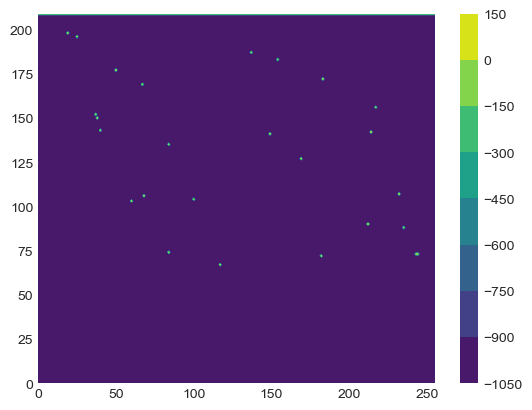

In [66]:
plt.contourf(np_salt[100, 27, :, :], cmap='viridis')
plt.colorbar()

## 10. Relaxation Coefficients (Lambda)

Define relaxation timescales for boundary conditions.

In [67]:
# Initialize lambda arrays
lambda_T = np.full((nt, nz, ny, nx), -999, dtype=np.float32)
lambda_S = np.full((nt, nz, ny, nx), -999, dtype=np.float32)
#lambda_u = np.full((nt, nz, ny, nx+1), -999, dtype=np.float32)
lambda_v = np.full((nt, nz, ny+1, nx), -999, dtype=np.float32)

# Ocean boundaries: 30-day relaxation timescale
lambda_ocean = 1.0 / (60 * 60 * 24 * 14)  # 1/(14 days in seconds)

# Northern boundary (y=-1, northern ocean)
lambda_T[:, :, -1, :] = lambda_ocean
lambda_S[:, :, -1, :] = lambda_ocean
#lambda_u[:, :, -1, :] = lambda_ocean
lambda_v[:, :, -1, :] = lambda_ocean

print(f"Ocean boundary lambda: {lambda_ocean:.2e} s⁻¹ (relaxation time: {1/lambda_ocean/86400:.1f} days)")

Ocean boundary lambda: 8.27e-07 s⁻¹ (relaxation time: 14.0 days)


In [68]:
lambda_S.shape

(366, 28, 210, 256)

In [69]:
# Calculate cell volumes and time-varying relaxation coefficients for river locations
R_earth = 6371e3  # Earth radius in meters

# Grid spacing
dlat = (lat_centers.max() - lat_centers.min()) / ny
dlon = (lon_centers.max() - lon_centers.min()) / nx
dy = R_earth * np.radians(dlat)

# Layer thicknesses (absolute values since z_faces are negative)
dz = np.abs(np.diff(z_faces))

print("\n=== Time-Varying River Relaxation Coefficients ===")
print(f"Computing λ(t) = Q(t) / V for each river and time step")
print(f"Time steps: {nt}")
print()

# Store cell volumes for each river
river_volumes = []

for i, (name, x, y) in enumerate(zip(river_names_final, xrivers, yrivers)):
    # Cell area
    lat_cell = lat_centers[y]
    dx = R_earth * np.radians(dlon) * np.cos(np.radians(lat_cell))
    area = dx * dy
    
    # Total volume (sum over all vertical layers)
    volumes = area * dz
    total_volume = volumes.sum()
    river_volumes.append(total_volume)
    
    # Get time series of discharge for this river
    Q_time = Q_rivers_time[:, i]  # Shape: (time,)
    
    # Calculate time-varying lambda: λ(t) = Q(t) / V
    lambda_river_time = Q_time / total_volume  # Shape: (time,)
    
    # Apply to all vertical layers for each time step
    # lambda_S has shape (nt, nz, ny, nx)
    for t in range(nt):
        lambda_S[t, :, y, x] = lambda_river_time[t]
    
    # Print statistics
    mean_Q = np.mean(Q_time)
    max_Q = np.max(Q_time)
    mean_lambda = np.mean(lambda_river_time)
    max_lambda = np.max(lambda_river_time)
    
    print(f"{name:25s}: V={total_volume:.0f} m³")
    print(f"  Q: mean={mean_Q:5.2f} m³/s, max={max_Q:5.2f} m³/s")
    print(f"  λ: mean={mean_lambda:.2e} s⁻¹ (τ={1/mean_lambda/86400:.1f} days), max={max_lambda:.2e} s⁻¹ (τ={1/max_lambda/86400:.1f} days)")
    print()

print("✓ Time-varying relaxation coefficients applied")


=== Time-Varying River Relaxation Coefficients ===
Computing λ(t) = Q(t) / V for each river and time step
Time steps: 366

Arnardalsá               : V=6337075 m³
  Q: mean= 2.68 m³/s, max= 8.38 m³/s
  λ: mean=4.23e-07 s⁻¹ (τ=27.4 days), max=1.32e-06 s⁻¹ (τ=8.8 days)

Blævardalsá              : V=6368006 m³
  Q: mean= 2.68 m³/s, max= 8.38 m³/s
  λ: mean=4.21e-07 s⁻¹ (τ=27.5 days), max=1.32e-06 s⁻¹ (τ=8.8 days)

Dalsá                    : V=6335578 m³
  Q: mean= 2.68 m³/s, max= 8.38 m³/s
  λ: mean=4.23e-07 s⁻¹ (τ=27.3 days), max=1.32e-06 s⁻¹ (τ=8.8 days)

Eyrardalsá               : V=6354041 m³
  Q: mean= 2.68 m³/s, max= 8.38 m³/s
  λ: mean=4.22e-07 s⁻¹ (τ=27.4 days), max=1.32e-06 s⁻¹ (τ=8.8 days)

Gljúfurá                 : V=6385455 m³
  Q: mean= 2.68 m³/s, max= 8.38 m³/s
  λ: mean=4.20e-07 s⁻¹ (τ=27.6 days), max=1.31e-06 s⁻¹ (τ=8.8 days)

Hafnardalsá              : V=6377479 m³
  Q: mean= 2.68 m³/s, max= 8.38 m³/s
  λ: mean=4.20e-07 s⁻¹ (τ=27.5 days), max=1.31e-06 s⁻¹ (τ=8.8 days)



## 11. Create Output Dataset

In [70]:
# Compute face coordinates
def compute_faces(centers):
    """Compute face coordinates from centers"""
    spacing = np.mean(np.diff(centers))
    faces = np.concatenate([
        [centers[0] - spacing/2],
        (centers[:-1] + centers[1:]) / 2,
        [centers[-1] + spacing/2]
    ])
    return faces

lon_faces = compute_faces(lon_centers)
lat_faces = compute_faces(lat_centers)

print(f"Coordinate faces computed:")
print(f"  lon_faces: {len(lon_faces)} ({lon_faces[0]:.4f}° to {lon_faces[-1]:.4f}°)")
print(f"  lat_faces: {len(lat_faces)} ({lat_faces[0]:.4f}° to {lat_faces[-1]:.4f}°)")

Coordinate faces computed:
  lon_faces: 257 (-23.3220° to -22.2980°)
  lat_faces: 211 (65.7590° to 66.1790°)


In [72]:
# Time coordinate
time_values = ds_interp.time.values

# Create output dataset
ds_out = xr.Dataset(
    {
        "T": (["time", "Nz", "Ny", "Nx"], np_temp),
        "T_lambda": (["time", "Nz", "Ny", "Nx"], lambda_T),
        "S": (["time", "Nz", "Ny", "Nx"], np_salt),
        "S_lambda": (["time", "Nz", "Ny", "Nx"], lambda_S),
        #"u": (["time", "Nz", "Ny", "Nx_faces"], np_u),
        #"u_lambda": (["time", "Nz", "Ny", "Nx_faces"], lambda_u),
        "v": (["time", "Nz", "Ny_faces", "Nx"], np_v),
        "v_lambda": (["time", "Nz", "Ny_faces", "Nx"], lambda_v),
    },
    coords={
        "time": time_values,
        "Nz": z_centers,
        "Ny": lat_centers,
        "Ny_faces": lat_faces,
        "Nx": lon_centers,
        "Nx_faces": lon_faces,
    },
)

# Add attributes
ds_out['T'].attrs = {'long_name': 'potential temperature', 'units': 'degrees_C'}
ds_out['S'].attrs = {'long_name': 'salinity', 'units': 'PSU'}
#ds_out['u'].attrs = {'long_name': 'u-velocity', 'units': 'm/s'}
ds_out['v'].attrs = {'long_name': 'v-velocity', 'units': 'm/s'}
ds_out['T_lambda'].attrs = {'long_name': 'temperature relaxation coefficient', 'units': '1/s'}
ds_out['S_lambda'].attrs = {'long_name': 'salinity relaxation coefficient', 'units': '1/s'}
#ds_out['u_lambda'].attrs = {'long_name': 'u-velocity relaxation coefficient', 'units': '1/s'}
ds_out['v_lambda'].attrs = {'long_name': 'v-velocity relaxation coefficient', 'units': '1/s'}

ds_out.attrs = {
    'title': 'Boundary conditions for Isafjardardju (210x256)',
    'source': 'CMEMS reanalysis + river inputs',
    'created': '2025-11-28',
    'grid': 'Isafjardardjup_bathymetry_210x256.nc',
    'rivers': f'{len(river_names)} rivers from isafjardardjup_rivers_wfs.nc',
}

print("\n=== Output Dataset ===")
print(ds_out)


=== Output Dataset ===
<xarray.Dataset> Size: 13GB
Dimensions:   (time: 366, Nz: 28, Ny: 210, Nx: 256, Ny_faces: 211, Nx_faces: 257)
Coordinates:
  * time      (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1992-01-01
  * Nz        (Nz) float64 224B -155.0 -145.0 -135.0 -125.0 ... -2.5 -1.5 -0.75
  * Ny        (Ny) float64 2kB 65.76 65.76 65.76 65.77 ... 66.17 66.18 66.18
  * Nx        (Nx) float64 2kB -23.32 -23.32 -23.31 ... -22.31 -22.3 -22.3
  * Ny_faces  (Ny_faces) float64 2kB 65.76 65.76 65.76 ... 66.17 66.18 66.18
  * Nx_faces  (Nx_faces) float64 2kB -23.32 -23.32 -23.31 ... -22.31 -22.3 -22.3
Data variables:
    T         (time, Nz, Ny, Nx) float32 2GB -999.0 -999.0 -999.0 ... 4.51 4.51
    T_lambda  (time, Nz, Ny, Nx) float32 2GB -999.0 -999.0 ... 8.267e-07
    S         (time, Nz, Ny, Nx) float32 2GB -999.0 -999.0 ... 35.05 35.05
    S_lambda  (time, Nz, Ny, Nx) float32 2GB -999.0 -999.0 ... 8.267e-07
    v         (time, Nz, Ny_faces, Nx) float32 2GB -999.0 -999.0 ... 

## 12. Fill Missing Values and Save

In [74]:
# Replace NaN with fill value

ds_out = ds_out.fillna(-999)

# Check for remaining NaN
nan_counts = {var: np.isnan(ds_out[var].values).sum() for var in ['T', 'S', 'v']}
print("NaN counts after fill:")
for var, count in nan_counts.items():
    print(f"  {var}: {count}")

if sum(nan_counts.values()) > 0:
    print("⚠️  Warning: NaN values remain in dataset")
else:
    print("✓ No NaN values in dataset")

NaN counts after fill:
  T: 0
  S: 0
  v: 0
✓ No NaN values in dataset


In [76]:
# Save full dataset (or subsample for testing)
output_file = 'C:/Users/fisa/Documents/Isafjord/input/Isf_bry_210x256rivers.nc'

## Option 1: Save every 3rd time step to reduce file size
#ds_out_subset = ds_out.isel(time=np.arange(0, nt, 3))
#print(f"Saving subset: {len(ds_out_subset.time)} time steps")
#ds_out_subset.to_netcdf(output_file)

# Option 2: Save full dataset (uncomment if needed)
ds_out.to_netcdf(output_file)

file_size_mb = os.path.getsize(output_file) / (1024**2)
print(f"\n✓ Boundary conditions saved to: {output_file}")
print(f"  File size: {file_size_mb:.1f} MB")


✓ Boundary conditions saved to: C:/Users/fisa/Documents/Isafjord/input/Isf_bry_210x256rivers.nc
  File size: 12629.9 MB


## 13. Verification

In [56]:
output_file = 'Isf_bry_299x315rivers.nc'

In [57]:
# Reload and verify
ds_verify = xr.open_dataset(output_file)

print("=== Verification ===")
print(ds_verify)

print("\n=== Variable Statistics ===")
for var in ['T', 'S', 'u', 'v']:
    data = ds_verify[var].values
    valid_data = data[(data != -999) & (data != -0)]
    print(f"{var:10s}: min={valid_data.min():8.3f}, max={valid_data.max():8.3f}, mean={valid_data.mean():8.3f}")

print("\n=== Required Variables ===")
required_vars = ['T', 'S', 'u', 'v', 'T_lambda', 'S_lambda', 'u_lambda', 'v_lambda']
missing = [v for v in required_vars if v not in ds_verify]
if missing:
    print(f"⚠️  Missing variables: {missing}")
else:
    print(f"✓ All required variables present")

ds_verify.close()
print("\n✓ Verification complete")

=== Verification ===
<xarray.Dataset> Size: 11GB
Dimensions:   (time: 122, Nz: 29, Ny: 315, Nx: 299, Nx_faces: 300, Ny_faces: 316)
Coordinates:
  * time      (time) datetime64[ns] 976B 1991-01-01 1991-01-04 ... 1991-12-30
  * Nz        (Nz) float64 232B -180.0 -160.0 -145.0 -135.0 ... -2.5 -1.5 -0.5
  * Ny        (Ny) float64 3kB 65.76 65.76 65.76 65.77 ... 66.38 66.39 66.39
  * Nx        (Nx) float64 2kB -23.49 -23.49 -23.48 ... -22.31 -22.3 -22.3
  * Nx_faces  (Nx_faces) float64 2kB -23.49 -23.49 -23.49 ... -22.31 -22.3 -22.3
  * Ny_faces  (Ny_faces) float64 3kB 65.76 65.76 65.76 ... 66.39 66.39 66.39
Data variables:
    T         (time, Nz, Ny, Nx) float32 1GB ...
    T_lambda  (time, Nz, Ny, Nx) float32 1GB ...
    S         (time, Nz, Ny, Nx) float32 1GB ...
    S_lambda  (time, Nz, Ny, Nx) float32 1GB ...
    u         (time, Nz, Ny, Nx_faces) float32 1GB ...
    u_lambda  (time, Nz, Ny, Nx_faces) float32 1GB ...
    v         (time, Nz, Ny_faces, Nx) float32 1GB ...
    v_lambda

In [58]:
xr.ufuncs.isnan(ds_verify['v']).sum()

<xarray.DataArray 'v' ()> Size: 8B
array(0)

## 14. Visualization Summary

TypeError: Input z must be 2D, not 4D

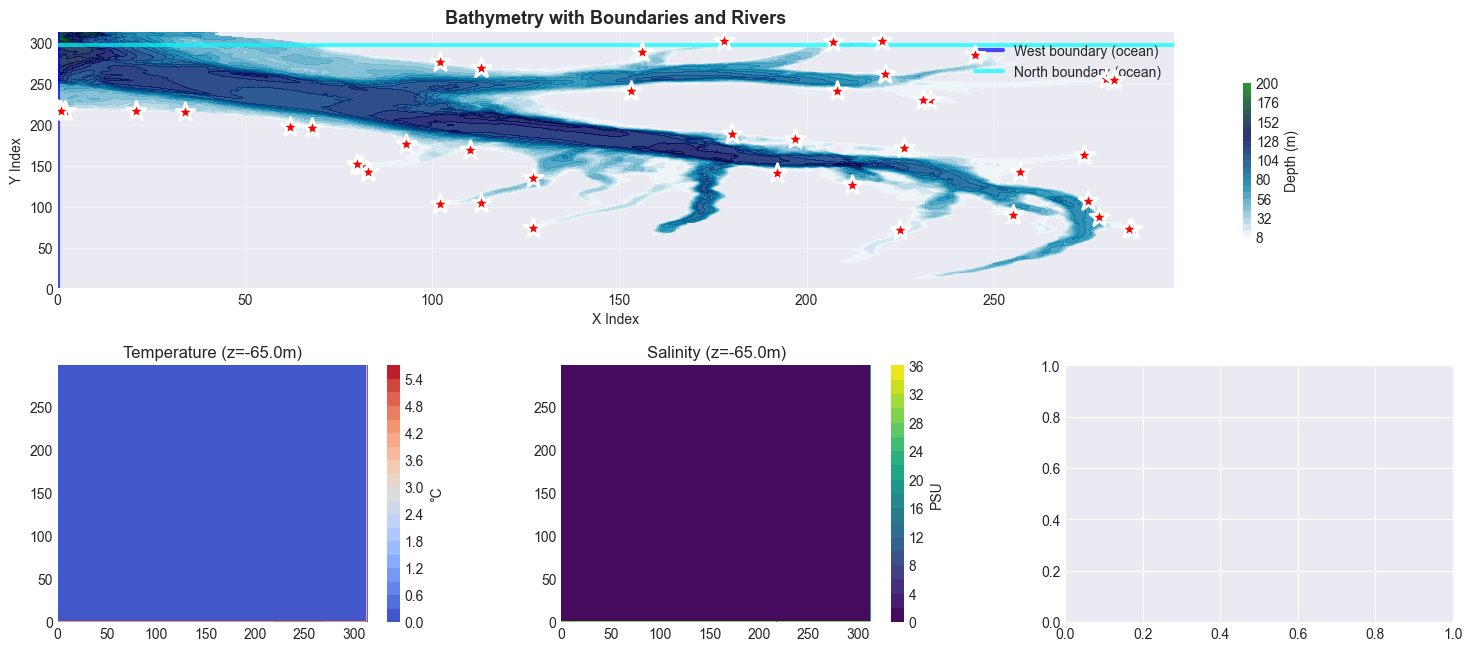

In [ ]:
# Final summary plot
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Bathymetry with boundaries
ax1 = fig.add_subplot(gs[0, :])
cf = ax1.contourf(depth_plot, levels=25, cmap='ocean_r', alpha=0.8)
# Mark boundaries
ax1.axvline(x=0, color='blue', linewidth=3, label='West boundary (ocean)', alpha=0.7)
ax1.axhline(y=nx-1, color='cyan', linewidth=3, label='North boundary (ocean)', alpha=0.7)
# Mark rivers
for i, (name, x, y) in enumerate(zip(river_names_final, xrivers, yrivers)):
    ax1.scatter(y, x, c='red', s=200, marker='*', edgecolors='white', linewidths=2, zorder=10)
    #ax1.text(y+5, x, name.split('_')[1], fontsize=9, color='red', fontweight='bold',
    #       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.colorbar(cf, ax=ax1, label='Depth (m)', shrink=0.6)
ax1.set_title('Bathymetry with Boundaries and Rivers', fontsize=13, fontweight='bold')
ax1.set_xlabel('X Index')
ax1.set_ylabel('Y Index')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Boundary conditions at mid-year
t_idx = len(ds_verify.time) // 2

ax2 = fig.add_subplot(gs[1, 0])
im = ax2.contourf(ds_verify['T'].isel(time=t_idx, Nz=10).T, levels=20, cmap='coolwarm')
plt.colorbar(im, ax=ax2, label='°C')
ax2.set_title(f'Temperature (z={z_centers[10]:.1f}m)')

ax3 = fig.add_subplot(gs[1, 1])
im = ax3.contourf(ds_verify['S'].isel(time=t_idx, Nz=10).T, levels=20, cmap='viridis')
plt.colorbar(im, ax=ax3, label='PSU')
ax3.set_title(f'Salinity (z={z_centers[10]:.1f}m)')

ax4 = fig.add_subplot(gs[1, 2])
speed = np.sqrt(ds_verify['u'].isel(time=t_idx, Nz=10, Nx_faces=slice(0,-1)).T**2 + 
                ds_verify['v'].isel(time=t_idx, Nz=10, Ny_faces=slice(0,-1)).T**2)
im = ax4.contourf(speed, levels=20, cmap='plasma')
plt.colorbar(im, ax=ax4, label='m/s')
ax4.set_title(f'Current Speed (z={z_centers[10]:.1f}m)')

# Time series at boundary
ax5 = fig.add_subplot(gs[2, 0])
ds_verify['T'].isel(Nx=0, Ny=ny//2, Nz=10).plot(ax=ax5, color='red')
ax5.set_title('Temperature at West Boundary')
ax5.set_ylabel('Temperature (°C)')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[2, 1])
ds_verify['S'].isel(Nx=0, Ny=ny//2, Nz=10).plot(ax=ax6, color='blue')
ax6.set_title('Salinity at West Boundary')
ax6.set_ylabel('Salinity (PSU)')
ax6.grid(True, alpha=0.3)

ax7 = fig.add_subplot(gs[2, 2])
# Show river influence (salinity at river locations)
for i, (name, x, y) in enumerate(zip(river_names_final, xrivers, yrivers)):
    ds_verify['S'].isel(Nx=y, Ny=x, Nz=0).plot(ax=ax7, label=name.split('_')[1])
ax7.set_title('Salinity at River Inputs (surface)')
ax7.set_ylabel('Salinity (PSU)')
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

plt.suptitle('Boundary Conditions Summary - Isafjardardju 299x315', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('Isf_BRY_299x315_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Summary visualization saved: Isf_BRY_299x315_summary.png")

## Summary

This notebook has created boundary condition files for the Isafjardardju simulation with:

### Grid Configuration
- **Dimensions**: 299 x 315 horizontal, 29 vertical layers
- **Bathymetry**: `Isafjardardjup_bathymetry299x315.nc`
- **Vertical grid**: Negative z-coordinates ordered from deepest (-190m) to surface (0m) - Oceananigans convention

### Boundary Conditions
1. **Ocean boundaries** (west and north edges):
   - Temperature, salinity, and velocity from CMEMS
   - 10-day relaxation timescale
   - Gaussian smoothing applied

2. **River inputs** (from WFS dataset):
   - Data source: `isafjardardjup_rivers_wfs.nc`
   - Number of rivers: Variable (all rivers with valid locations)
   - Freshwater input (salinity = 0)
   - Discharge-based relaxation coefficients
   - Grid locations automatically mapped

### Output File
- **Filename**: `Isf_bry_299x315.nc`
- **Variables**: T, S, u, v (with corresponding lambda coefficients)
- **Format**: NetCDF compatible with FjordsSim.jl

The file is ready for use with the `forcing_from_file` function in FjordsSim.jl.